## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

## Load Dataset

In [4]:
df = pd.read_csv("Final_RF_VLC_HYBRID_OPTIMIZED.csv")

print(df.head())
print(df.columns)

     distance       speed  relative_speed  vehicle_density  fog_beta  \
0   68.307753   40.309515       54.557415        23.301086       0.0   
1   31.870232   92.775463        6.761487        22.892134       0.0   
2  200.000000   17.019959        7.996024        27.775375       0.0   
3   89.748509   58.537492       47.318870        29.343995       0.0   
4  137.932312  107.100592       62.165040        69.407269       0.0   

   rain_rate  weather_class  link_label  LOS       SNR_rf     SNR_vlc  
0        0.0              1           3    1   369.022278   12.417605  
1        0.0              1           3    1  5325.718607  103.675519  
2        0.0              1           2    1     2.282936    2.592297  
3        0.0              1           2    1    12.416650    7.874429  
4        0.0              1           1    0     3.271500    0.461525  
Index(['distance', 'speed', 'relative_speed', 'vehicle_density', 'fog_beta',
       'rain_rate', 'weather_class', 'link_label', 'LOS', 

## Define Features and Target

In [5]:
# Example feature columns
features = ['distance','speed','relative_speed','vehicle_density', 'rain_rate','LOS',
       'weather_class', 'SNR_rf', 'SNR_vlc',]

# Target (1 = RF, 2 = VLC, 3 = Hybrid)
target = 'link_label'

# Ensure the target column is numeric, coercing errors to NaN
df[target] = pd.to_numeric(df[target], errors='coerce')

# Drop rows where the target variable is NaN
df.dropna(subset=[target], inplace=True)

X = df[features]
y = df[target].astype(int) # Convert to integer type for classification

# Verify no NaNs remain in y
if y.isnull().sum() > 0:
    raise ValueError("NaNs still present in target variable after cleaning.")

## Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,stratify=y
)

## Train Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    min_samples_split=10,
    min_samples_leaf=8,
    max_features='sqrt'
    )
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=8, min_samples_split=10,
                       random_state=42)

## Prediction and Accuracy

In [8]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8970555555555556

Classification Report:
               precision    recall  f1-score   support

           1       0.97      0.94      0.95      5627
           2       0.89      0.78      0.83      4866
           3       0.86      0.94      0.90      7507

    accuracy                           0.90     18000
   macro avg       0.90      0.89      0.89     18000
weighted avg       0.90      0.90      0.90     18000



## Confusion Matrix

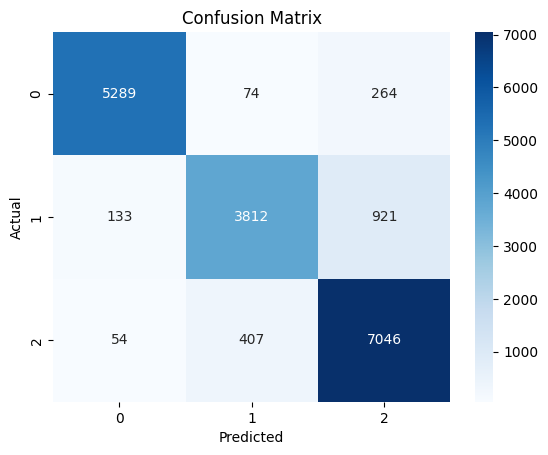

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ROC Curve

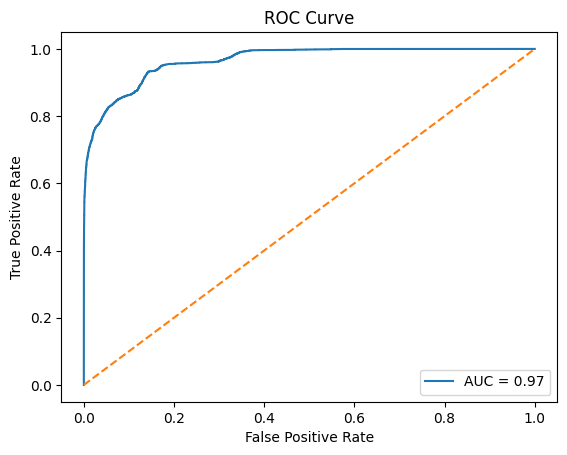

In [10]:
y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Correlation Matrix

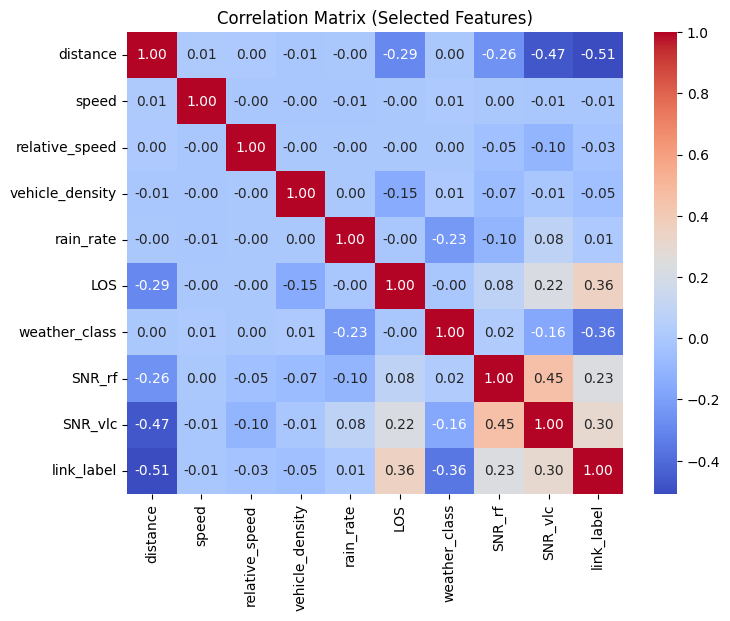

In [11]:
# ================= SELECT FEATURES =================
selected_features = [
    'distance','speed','relative_speed','vehicle_density',
    'rain_rate','LOS','weather_class','SNR_rf', 'SNR_vlc','link_label'
]

# ================= COMPUTE CORRELATION =================
corr_matrix = df[selected_features].corr()

# ================= PLOT =================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix (Selected Features)")
plt.show()

## Feature Importance

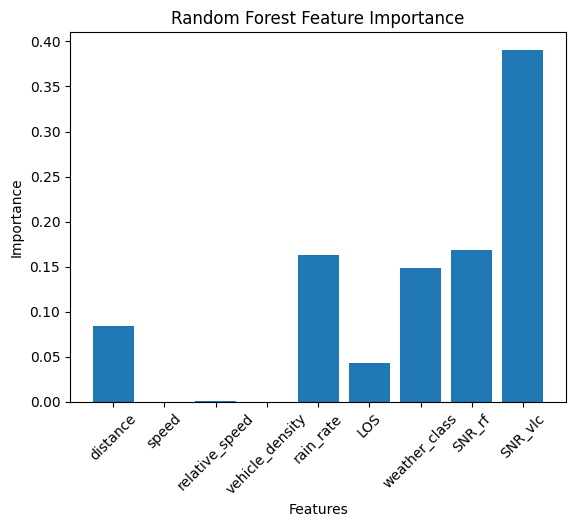

In [12]:
importance = rf.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

## Distance vs Link Selection

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Re-load the dataset and define features/target for robustness
# This ensures X_train, y_train etc. are defined even if previous cells weren't run.
df = pd.read_csv("Final_RF_VLC_HYBRID_OPTIMIZED.csv")

features = ['distance','speed','relative_speed','vehicle_density', 'rain_rate','LOS',
       'weather_class', 'SNR_rf', 'SNR_vlc']

target = 'link_label'

# Ensure the target column is numeric, coercing errors to NaN
df[target] = pd.to_numeric(df[target], errors='coerce')
# Drop rows where the target variable is NaN
df.dropna(subset=[target], inplace=True)

X = df[features]
# Convert target to 0-indexed for consistency with XGBoost multi-class
y = df[target].astype(int) - 1

# 2. Re-perform Train-Test Split (as done for RF)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 1. Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# 2. XGBoost
xgb = XGBClassifier(n_estimators=50, max_depth=2, gamma=0.4, subsample=0.6, colsample_bytree=0.6, random_state=42, eval_metric='mlogloss', num_class=3)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

Decision Tree Accuracy: 0.8883888888888889
XGBoost Accuracy: 0.9293888888888889


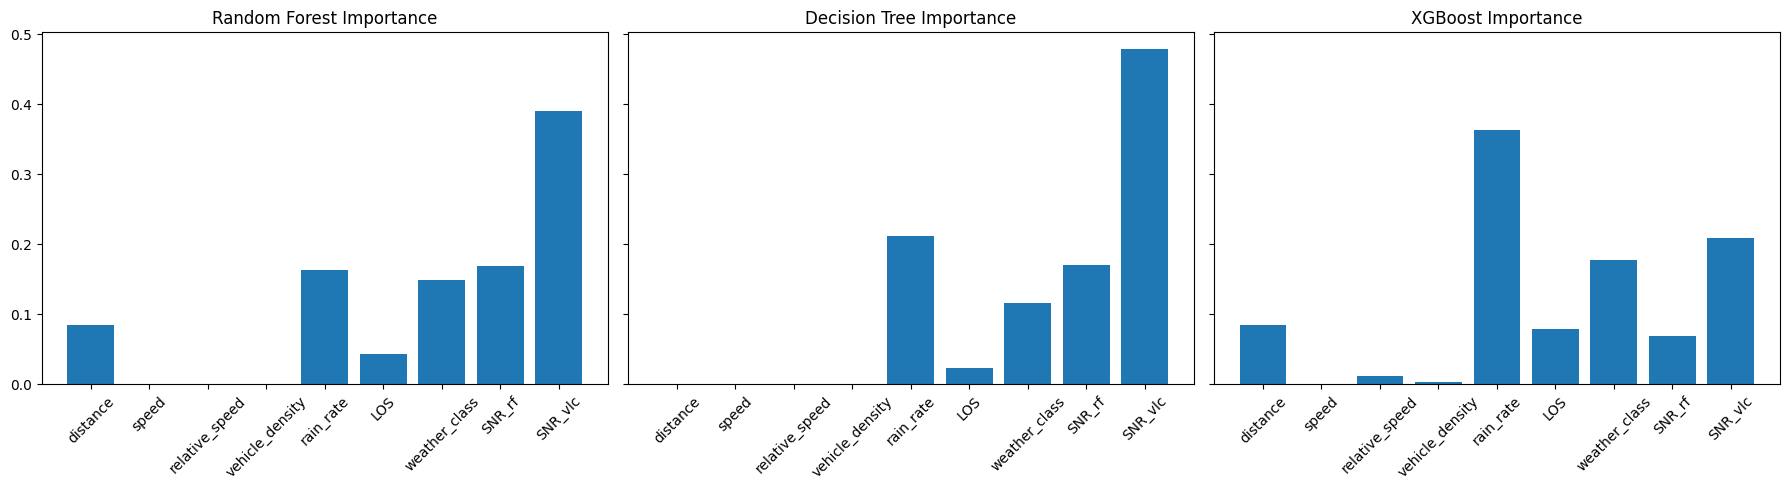

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = [rf, dt, xgb]
titles = ['Random Forest', 'Decision Tree', 'XGBoost']

# All models were trained with the 'features' list (9 features) defined in H-kVe3lxNxzw
# The lists features_8 and features_7 are not needed and were causing the mismatch.

for ax, model, title in zip(axes, models, titles):
    # Use the global 'features' variable which contains 9 feature names
    ax.bar(features, model.feature_importances_)
    ax.set_title(f"{title} Importance")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

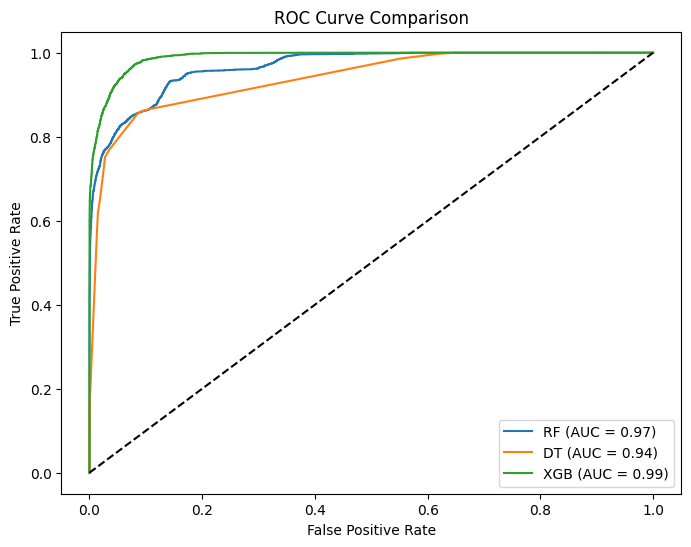

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # Keep for potential future scaling, but not used for DT/XGB here

# Load the dataset to ensure 'df' is available and fresh
df = pd.read_csv("Final_RF_VLC_HYBRID_OPTIMIZED.csv")

# Global features list used for training RF, DT, and XGB models (from cell H-kVe3lxNxzw)
# This list is: ['distance','speed','relative_speed','vehicle_density', 'rain_rate','LOS','weather_class', 'SNR_rf', 'SNR_vlc']
# This variable 'features' is accessible from the kernel state.

# --- Data preparation for Random Forest ---
# RF model was trained with 1-indexed labels and the global 'features' list.
# Re-create the RF-specific test set with 1-indexed labels.
df_rf_roc_data = df.copy()
df_rf_roc_data['link_label'] = pd.to_numeric(df_rf_roc_data['link_label'], errors='coerce')
df_rf_roc_data.dropna(subset=['link_label'], inplace=True)
y_rf_roc_true = df_rf_roc_data['link_label'].astype(int) # 1-indexed labels
X_rf_roc_data = df_rf_roc_data[features] # Use the global 'features' list

_, X_test_rf_roc, _, y_test_rf_roc_labels = train_test_split(
    X_rf_roc_data, y_rf_roc_true, test_size=0.3, random_state=42, stratify=y_rf_roc_true
)

# --- Data preparation for Decision Tree and XGBoost ---
# DT and XGB models were trained with 0-indexed labels and the global 'features' list, and NOT scaled.
# Re-create the DT/XGB-specific test set with 0-indexed labels.
df_dt_xgb_roc_data = df.copy()
df_dt_xgb_roc_data['link_label'] = pd.to_numeric(df_dt_xgb_roc_data['link_label'], errors='coerce')
df_dt_xgb_roc_data.dropna(subset=['link_label'], inplace=True)
y_dt_xgb_roc_true = df_dt_xgb_roc_data['link_label'] - 1 # 0-indexed labels
X_dt_xgb_roc_data = df_dt_xgb_roc_data[features] # Use the global 'features' list

_, X_test_dt_xgb_roc, _, y_test_dt_xgb_roc_labels = train_test_split(
    X_dt_xgb_roc_data, y_dt_xgb_roc_true, test_size=0.3, random_state=42, stratify=y_dt_xgb_roc_true
)

plt.figure(figsize=(8, 6))

# RF
# RF model trained on 1-indexed labels (1, 2, 3). For pos_label=2, we need the probability of class 2.
# Find the index of class 2 in the unique classes the model was trained on
rf_class_idx_for_pos_label_2 = list(rf.classes_).index(2)
y_prob_rf = rf.predict_proba(X_test_rf_roc)[:, rf_class_idx_for_pos_label_2] # Use corrected X_test
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf_roc_labels, y_prob_rf, pos_label=2) # Use corrected y_test
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc(fpr_rf, tpr_rf):.2f})")

# DT
# DT model trained on 0-indexed labels (0, 1, 2). For original class 2 (now 0-indexed class 1), pos_label=1.
dt_class_idx_for_pos_label_1 = list(dt.classes_).index(1)
y_prob_dt = dt.predict_proba(X_test_dt_xgb_roc)[:, dt_class_idx_for_pos_label_1] # Use corrected X_test
fpr_dt, tpr_dt, _ = roc_curve(y_test_dt_xgb_roc_labels, y_prob_dt, pos_label=1) # Use corrected y_test
plt.plot(fpr_dt, tpr_dt, label=f"DT (AUC = {auc(fpr_dt, tpr_dt):.2f})")

# XGB
# XGB model trained on 0-indexed labels (0, 1, 2). For original class 2 (now 0-indexed class 1), pos_label=1.
xgb_class_idx_for_pos_label_1 = list(xgb.classes_).index(1)
y_prob_xgb = xgb.predict_proba(X_test_dt_xgb_roc)[:, xgb_class_idx_for_pos_label_1] # Use corrected X_test
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_dt_xgb_roc_labels, y_prob_xgb, pos_label=1) # Use corrected y_test
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {auc(fpr_xgb, tpr_xgb):.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

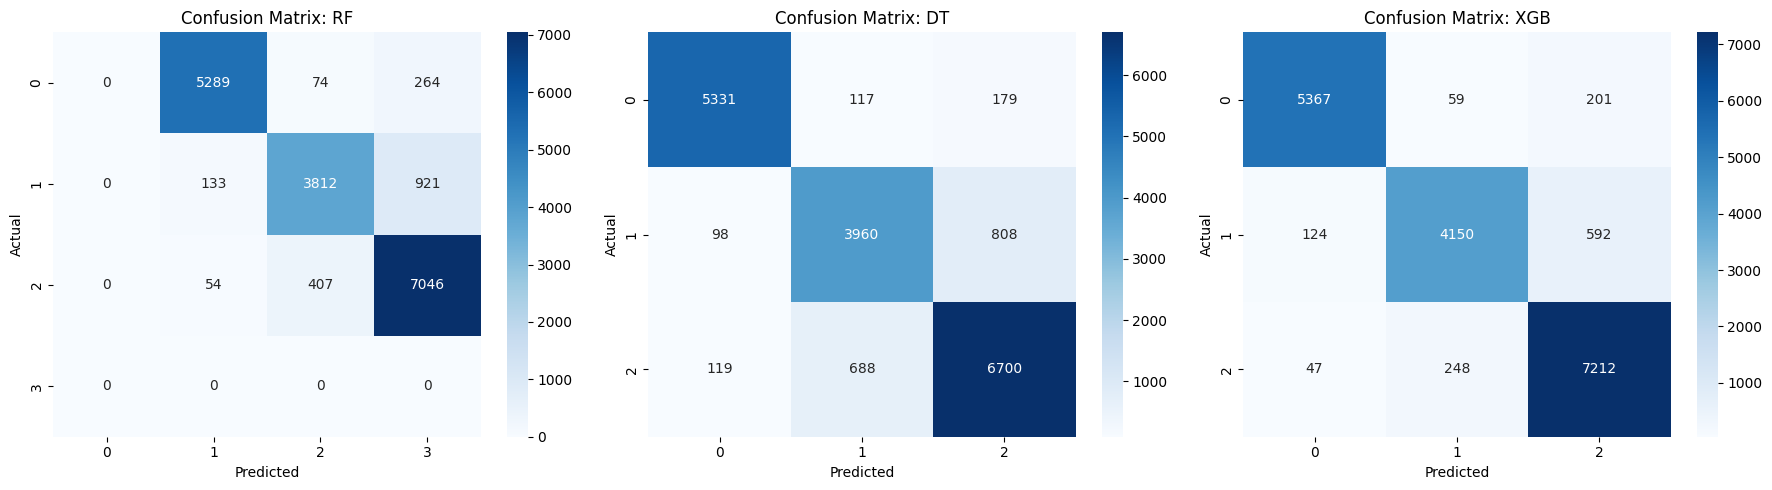

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_rf = confusion_matrix(y_test, y_pred)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plots = [(cm_rf, 'RF'), (cm_dt, 'DT'), (cm_xgb, 'XGB')]

for ax, (cm, title) in zip(axes, plots):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix: {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

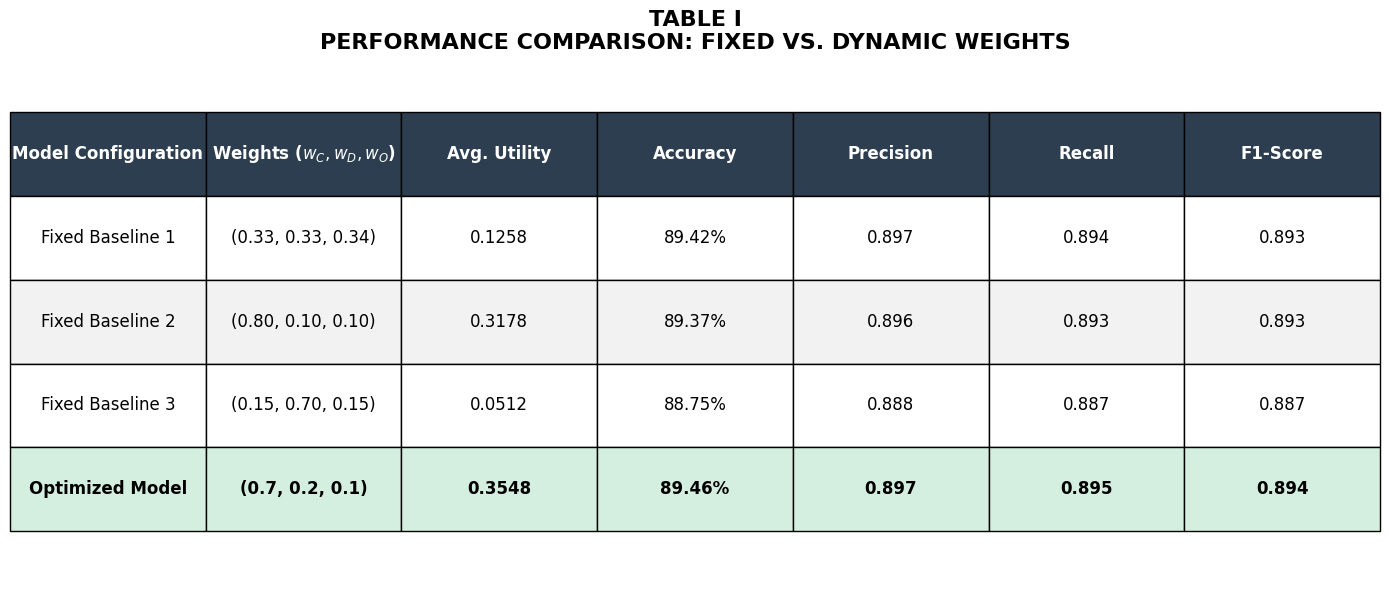

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Rows - Fixed syntax error in Baseline 3
rows = [
    ["Fixed Baseline 1", "(0.33, 0.33, 0.34)", "0.1258", "89.42%", "0.897", "0.894", "0.893"],
    ["Fixed Baseline 2", "(0.80, 0.10, 0.10)", "0.3178", "89.37%", "0.896", "0.893", "0.893"],
    ["Fixed Baseline 3", "(0.15, 0.70, 0.15)", "0.0512", "88.75%", "0.888", "0.887", "0.887"], # Added [ and %
    ["Optimized Model", "(0.7, 0.2, 0.1)", "0.3548", "89.46%", "0.897", "0.895", "0.894"]
]

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

cols = ["Model Configuration", "Weights ($w_C, w_D, w_O$)", "Avg. Utility", "Accuracy", "Precision", "Recall", "F1-Score"]
table = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)

# 3. Increase Table Length (Vertical Scaling)
table.scale(1, 4.5)

# 4. Professional Styling
header_color = '#2c3e50'
row_even_color = '#f2f2f2'
highlight_color = '#d4efdf'

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', weight='bold')
    elif row == len(rows): # Optimized Model Row
        cell.set_facecolor(highlight_color)
        cell.set_text_props(weight='bold')
    elif row % 2 == 0 and row != 0:
        cell.set_facecolor(row_even_color)

# 5. Adjusted Title
plt.title('TABLE I\nPERFORMANCE COMPARISON: FIXED VS. DYNAMIC WEIGHTS',
          fontweight='bold', fontsize=16, pad=10)

plt.tight_layout()
fig.savefig('ieee_table_final.png', dpi=300, bbox_inches='tight')
plt.show()